# 1. Featurization

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
np.bool=np.bool_

import pyemma
from pyemma.util.contexts import settings

from msmbuilder.io import load_trajs, load_generic

import os
import random

#### Load trajectories and topology
* Save all trajectories and the top file (trjconv -dump 0) into a folder called 'data' AND THEN process with the code below

In [2]:
pdb= './data/top.pdb'
files = []
indir="./data"
for filename in os.listdir(indir):
    if filename.endswith('.xtc'):
        files.append(os.path.join(indir,filename))
files = sorted(files, key=lambda x: int(os.path.splitext(os.path.basename(x))[0]))

print("Topology: " + pdb)
print("Trajectories: "+ str(files))

Topology: ./data/top.pdb
Trajectories: ['./data/0.xtc', './data/1.xtc', './data/2.xtc', './data/3.xtc', './data/4.xtc', './data/5.xtc', './data/6.xtc', './data/7.xtc', './data/8.xtc', './data/9.xtc', './data/10.xtc', './data/11.xtc', './data/12.xtc', './data/13.xtc', './data/14.xtc', './data/15.xtc', './data/16.xtc', './data/17.xtc', './data/18.xtc', './data/19.xtc']


In [102]:
import os
import pyemma
import numpy as np

# Create the 'feat' directory if it doesn't exist
os.makedirs('feat', exist_ok=True)

# Load the features using PyEmma
torsions_feat = pyemma.coordinates.featurizer(pdb)
torsions_feat.add_backbone_torsions(cossin=True, periodic=True)
torsions_data = pyemma.coordinates.load(files, features=torsions_feat)
print(len(torsions_data[0][0]))

Obtaining file info:   0%|                               | 0/20 [00:00<?, ?it/s]

getting output of FeatureReader:   0%|                   | 0/20 [00:00<?, ?it/s]

196


In [103]:
os.makedirs('feat', exist_ok=True)
for i, traj in enumerate(torsions_data):
    file_path = os.path.join('feat', f'{i}.npy')
    np.save(file_path, traj)

# 2. TICA

In [104]:
from msmbuilder.io import gather_metadata, save_meta, NumberedRunsParser

## Change step_ps to amount of time per step
parser = NumberedRunsParser(
    traj_fmt="{run}.xtc",
    top_fn="data/top.pdb",
    step_ps=100,
)
meta = gather_metadata("data/*.xtc", parser)
save_meta(meta)

/home/samueltien/.conda/envs/pyemma/lib/python3.11/site-packages/msmbuilder/io/io.py:52: BackupWarning: meta.pandas.pickl exists. Moving it to meta.pandas.pickl.bak.7
  warnings.warn("{fn} exists. Moving it to {newfn}"


In [105]:
from msmbuilder.io import load_trajs, save_trajs, save_generic
from msmbuilder.decomposition import tICA

data_dir = 'feat'
## Load
tica = tICA(n_components=10, lag_time=100, kinetic_mapping=True)
meta, ftrajs = load_trajs(data_dir)

## Fit
tica.fit(ftrajs.values())

## Transform
ttrajs = {}
for k, v in ftrajs.items():
    ttrajs[k] = tica.partial_transform(v)

## Save
save_trajs(ttrajs, 'ttrajs', meta)
save_generic(tica, 'tica.pickl')

/home/samueltien/.conda/envs/pyemma/lib/python3.11/site-packages/msmbuilder/io/io.py:52: BackupWarning: ttrajs exists. Moving it to ttrajs.bak.7
  warnings.warn("{fn} exists. Moving it to {newfn}"
/home/samueltien/.conda/envs/pyemma/lib/python3.11/site-packages/msmbuilder/io/io.py:52: BackupWarning: tica.pickl exists. Moving it to tica.pickl.bak.7
  warnings.warn("{fn} exists. Moving it to {newfn}"


#### Plot histogram

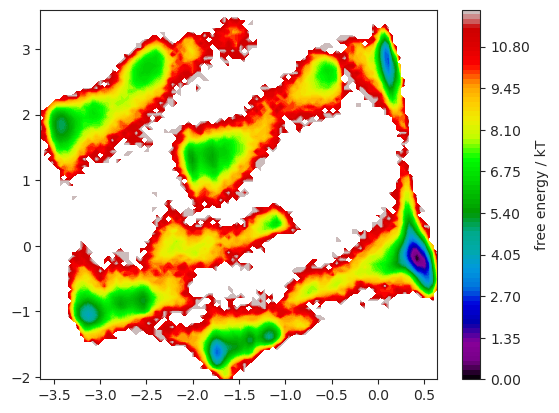

In [106]:
import matplotlib
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import pyemma.plots as mplt

from msmbuilder.io import load_trajs, load_generic

sns.set_style('ticks')
colors = sns.color_palette()

## Load
tica = load_generic('tica.pickl')
meta, ttrajs = load_trajs('ttrajs')
txx = np.concatenate(list(ttrajs.values()))

## Plot 1
mplt.plot_free_energy(np.vstack(txx)[:,0], np.vstack(txx)[:,1])
plt.savefig('2_3_tica-heatmap.png')

# 3. Cluster

In [107]:
from msmbuilder.io import load_trajs, save_trajs, save_generic
from msmbuilder.cluster import MiniBatchKMeans

## Load
meta, ttrajs = load_trajs('ttrajs')

## Fit
kclusters = MiniBatchKMeans(n_clusters=200)
kclusters.fit([traj for traj in ttrajs.values()])

## Transform
ktrajs = {}
for k, v in ttrajs.items():
    ktrajs[k] = kclusters.partial_transform(v)

## Save
#print(kmeans.summarize())
save_trajs(ktrajs, 'ktrajs', meta)
save_generic(kclusters, 'kclusters.pickl')

/home/samueltien/.conda/envs/pyemma/lib/python3.11/site-packages/msmbuilder/io/io.py:52: BackupWarning: ktrajs exists. Moving it to ktrajs.bak.7
  warnings.warn("{fn} exists. Moving it to {newfn}"
/home/samueltien/.conda/envs/pyemma/lib/python3.11/site-packages/msmbuilder/io/io.py:52: BackupWarning: kclusters.pickl exists. Moving it to kclusters.pickl.bak.7
  warnings.warn("{fn} exists. Moving it to {newfn}"


#### Plot clusters on TICA coords

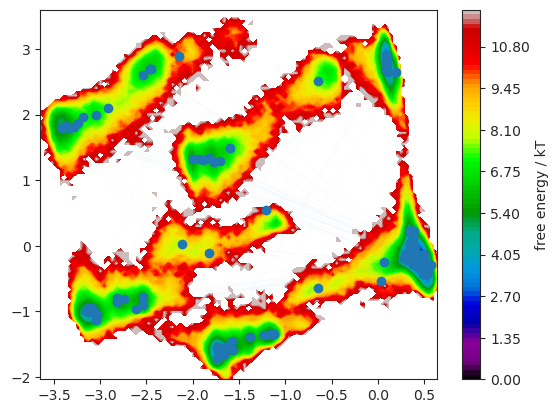

In [19]:
import matplotlib
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import pyemma.plots as mplt

from msmbuilder.io import load_trajs, load_generic

sns.set_style('ticks')
colors = sns.color_palette()

## Load
kclusters = load_generic('kclusters.pickl')
meta, ktrajs = load_trajs('ktrajs')
meta, ttrajs = load_trajs('ttrajs', meta)
txx = np.concatenate(list(ttrajs.values()))


mplt.plot_free_energy(np.vstack(txx)[:,0], np.vstack(txx)[:,1])
plt.plot(kclusters.cluster_centers_[:, 0], kclusters.cluster_centers_[:, 1], linewidth=0.01, marker='o')
plt.savefig('2_ticawithclusters.png')
plt.show()

### 3.3 Sample clusters and get structures (OPTIONAL)

/home/samueltien/.conda/envs/pyemma/lib/python3.11/site-packages/msmbuilder/io/io.py:52: BackupWarning: cluster-sample-inds.pickl exists. Moving it to cluster-sample-inds.pickl.bak.1
  warnings.warn("{fn} exists. Moving it to {newfn}"
/home/samueltien/.conda/envs/pyemma/lib/python3.11/site-packages/msmbuilder/io/io.py:52: BackupWarning: 2_cluster_samples exists. Moving it to 2_cluster_samples.bak.1
  warnings.warn("{fn} exists. Moving it to {newfn}"
/tmp/ipykernel_158999/2589386977.py:66: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(coo[:, 0], coo[:, 1], c=colors[i % 6], s=40)


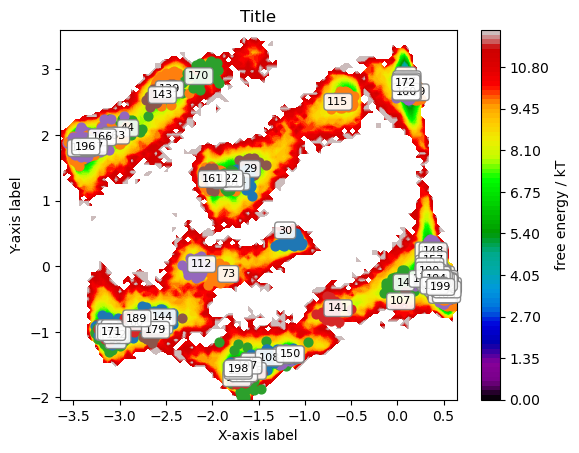

In [3]:
import mdtraj as md
import os

from msmbuilder.io.sampling import sample_states
from msmbuilder.io import load_trajs, save_generic, preload_top, backup, load_generic

import matplotlib
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import pyemma.plots as mplt

#matplotlib.use("Agg")

## Load
meta, ttrajs = load_trajs('ttrajs')
kclusters = load_generic("kclusters.pickl")

## Sample
inds = sample_states(ttrajs,
                     kclusters.cluster_centers_,
                     k=30)

save_generic(inds, "cluster-sample-inds.pickl")

## Make trajectories
top = preload_top(meta)
out_folder = "2_cluster_samples"
backup(out_folder)
os.mkdir(out_folder)

index_file = os.path.join(out_folder, "index.txt")

with open(index_file, 'w') as f:
    f.write("State\tTrajectory\tFrame\n")  # Header

    for state_i, state_inds in enumerate(inds):
        traj = md.join(
            md.load_frame(meta.loc[traj_i]['traj_fn'], index=frame_i, top=top)
            for traj_i, frame_i in state_inds
        )
        traj.save("{}/{}.xtc".format(out_folder, state_i))

        # Write the indices to the file
        for traj_i, frame_i in state_inds:
            f.write(f"{state_i}\t{traj_i}\t{frame_i}\n")

colors = sns.color_palette()

## Load
meta, ttrajs = load_trajs('ttrajs')
txx = np.concatenate(list(ttrajs.values()))
kclusters = load_generic('kclusters.pickl')

inds = load_generic("cluster-sample-inds.pickl")
coordinates = [
    np.asarray([ttrajs[traj_i][frame_i, :] for traj_i, frame_i in state_inds])
    for state_inds in inds
    ]


mplt.plot_free_energy(np.vstack(txx)[:,0], np.vstack(txx)[:,1])

# Overlay scatter plot of cluster centers and their indices
for i, coo in enumerate(coordinates):
    plt.scatter(coo[:, 0], coo[:, 1], c=colors[i % 6], s=40)
    plt.text(kclusters.cluster_centers_[i, 0],
             kclusters.cluster_centers_[i, 1],
             "{}".format(i),
             ha='center',
             va='center',
             size=8,
             bbox=dict(
                 boxstyle='round',
                 fc='w',
                 ec="0.5",
                 alpha=0.9,
             ),
             zorder=10,
             )
plt.xlabel('X-axis label')
plt.ylabel('Y-axis label')
plt.title('Title')
plt.savefig('2_trajectorieswithclusters.png')

# 4. MSM validation

#### Implied timescales no error bars (quick)

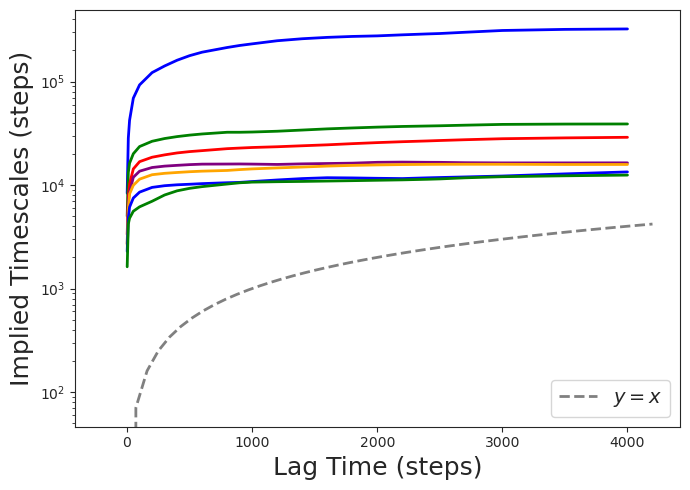

In [108]:
import numpy as np
import os
import matplotlib.pyplot as plt
from multiprocessing import Pool
import pandas as pd
from msmbuilder.io import load_trajs
import deeptime

# Function to load reduced data
def load_reduced_data(data_dir, stride):
    reduced_files = sorted([f for f in os.listdir(data_dir) if f.endswith('.npy')])
    reduced_data = [np.load(os.path.join(data_dir, f)) for f in reduced_files]
    reduced_data = [data[::stride] for data in reduced_data]
    return reduced_data

# Load discrete trajectories
discrete_trajs = load_reduced_data("ktrajs", 1)

# Specify lag times
lagtimes = [1, 10, 20, 50, 100, 200, 300, 400, 500, 600,800,900, 1000, 1200, 1400, 1600, 1800, 2000,2200,2400,2500,2700,3000,3500,4000]

# Fit models for each lag time
models = []
for lag in lagtimes:
    counts = deeptime.markov.TransitionCountEstimator(lagtime=lag, count_mode="sliding").fit_fetch(discrete_trajs)
    msm = deeptime.markov.msm.MaximumLikelihoodMSM().fit_from_counts(counts).fetch_model()
    models.append(msm)

# Extract timescales for plotting
timescales_data = []
for model in models:
    timescales = model.timescales()[:7]  # Get the first 7 timescales
    timescales_data.append(timescales)

# Convert to DataFrame for easier plotting
timescales_df = pd.DataFrame(timescales_data, columns=[f'timescale_{i}' for i in range(len(timescales_data[0]))])
timescales_df['lag_time'] = lagtimes

# Plot implied timescales vs. lag time
def plot_timescales(ax):
    line_colours = ['blue', 'green', 'red', 'purple', 'orange']
    
    # Iterate over timescales and plot
    for i in range(len(timescales_df.columns) - 1):  # Exclude lag_time column
        ax.plot(timescales_df['lag_time'],
                timescales_df[f'timescale_{i}'],
                linewidth=2, color=line_colours[i % len(line_colours)],
                label=None  # pandas interference
                )
    
    xmin, xmax = ax.get_xlim()
    xx = np.linspace(xmin, xmax)
    ax.plot(xx, xx, linestyle='--', color='gray', label='$y=x$', linewidth=2)
    ax.legend(loc='best', fontsize=14)
    ax.set_xlabel('Lag Time (steps)', fontsize=18)
    ax.set_ylabel('Implied Timescales (steps)', fontsize=18)
    ax.set_yscale('log')

# Create figure and axis for plotting
fig, ax = plt.subplots(figsize=(7, 5))
plot_timescales(ax)
fig.tight_layout()
fig.savefig('3_impled-timescales.png')
plt.show()


#### Implied timescales error bars

In [13]:
import numpy as np
import os
import matplotlib.pyplot as plt
from multiprocessing import Pool
import pandas as pd
from msmbuilder.io import load_trajs
import deeptime

# Function to load reduced data
def load_reduced_data(data_dir, stride):
    reduced_files = sorted([f for f in os.listdir(data_dir) if f.endswith('.npy')])
    reduced_data = [np.load(os.path.join(data_dir, f)) for f in reduced_files]
    reduced_data = [data[::stride] for data in reduced_data]
    return reduced_data

# Load discrete trajectories
discrete_trajs = load_reduced_data("ktrajs", 1)

# Specify lag times
lagtimes = [1, 10, 20, 50, 100, 200, 300, 400, 500, 600, 1000, 1200, 1400, 1600,2000,2500,3000]

# Fit models for each lag time
mlemodels = []
baymodels = []


for lag in lagtimes:
    bcounts = deeptime.markov.TransitionCountEstimator(lagtime=lag, count_mode="effective").fit_fetch(discrete_trajs)
    bmsm = deeptime.markov.msm.BayesianMSM().fit(bcounts).fetch_model()
    baymodels.append(bmsm)
    counts = deeptime.markov.TransitionCountEstimator(lagtime=lag, count_mode="sliding").fit_fetch(discrete_trajs)
    msm = deeptime.markov.msm.MaximumLikelihoodMSM().fit_from_counts(counts).fetch_model()
    mlemodels.append(msm)
    print(lag)

1
10
20
50
100
200
300
400
500
600
1000
1200
1400
1600
2000
2500
3000


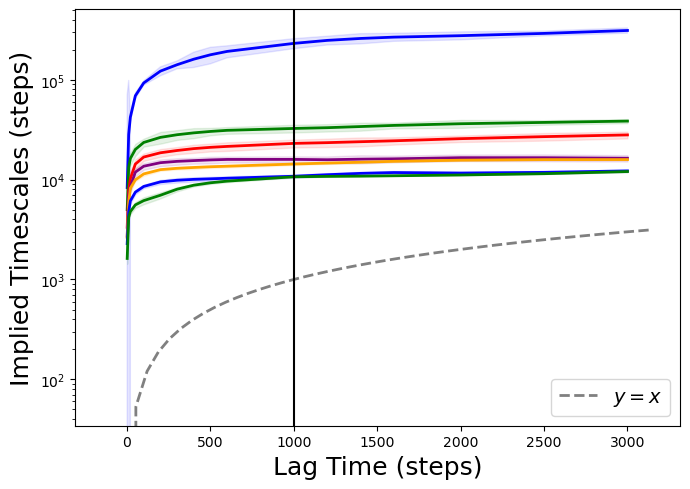

In [14]:
import math

timescales_data = []
for model in mlemodels:
    timescales = model.timescales()[:7]  # Get the first 7 timescales
    timescales_data.append(timescales)

# Extract timescales for plotting

errors_data = []
for model in baymodels:
    #timescales = model.gather_stats("timescales").mean[:7]  # Get the first 7 timescales
    #timescales_data.append(timescales)
    errors = model.gather_stats("timescales").std[:7]  # Get the first 7 timescales
    #errors = [np.log(error) for error in errors]
    errors = [error / 2 for error in errors]
    errors_data.append(errors)

    



timescales_df = pd.DataFrame(timescales_data, columns=[f'timescale_{i}' for i in range(len(timescales_data[0]))])
timescales_df['lag_time'] = lagtimes

errors_df = pd.DataFrame(errors_data, columns=[f'timescale_{i}' for i in range(len(errors_data[0]))])
errors_df['lag_time'] = lagtimes

# Plot implied timescales vs. lag time
def plot_timescales(ax):
    line_colours = ['blue', 'green', 'red', 'purple', 'orange']
    
    # Iterate over timescales and plot
    for i in range(len(timescales_df.columns) - 1):  # Exclude lag_time column
        ax.plot(timescales_df['lag_time'],
                timescales_df[f'timescale_{i}'],
                linewidth=2, color=line_colours[i % len(line_colours)],
                label=None  # pandas interference
                )
        ax.fill_between(timescales_df['lag_time'],
            timescales_df[f'timescale_{i}'] - errors_df[f'timescale_{i}'],
            timescales_df[f'timescale_{i}'] + errors_df[f'timescale_{i}'],
            color=line_colours[i % len(line_colours)],
            alpha=0.1)  # Adjust transparency
    
    xmin, xmax = ax.get_xlim()
    xx = np.linspace(xmin, xmax)
    ax.plot(xx, xx, linestyle='--', color='gray', label='$y=x$', linewidth=2)
    ax.legend(loc='lower right', fontsize=14)
    ax.set_xlabel('Lag Time (steps)', fontsize=18)
    ax.set_ylabel('Implied Timescales (steps)', fontsize=18)
    ax.set_yscale('log')
    ax.axvline(x=1000, color='black', label='x = 1000')



# Create figure and axis for plotting
fig, ax = plt.subplots(figsize=(7, 5))
plot_timescales(ax)
fig.tight_layout()
fig.savefig('3_implied-timescales.png')
plt.show()


#### Spectral decomposition

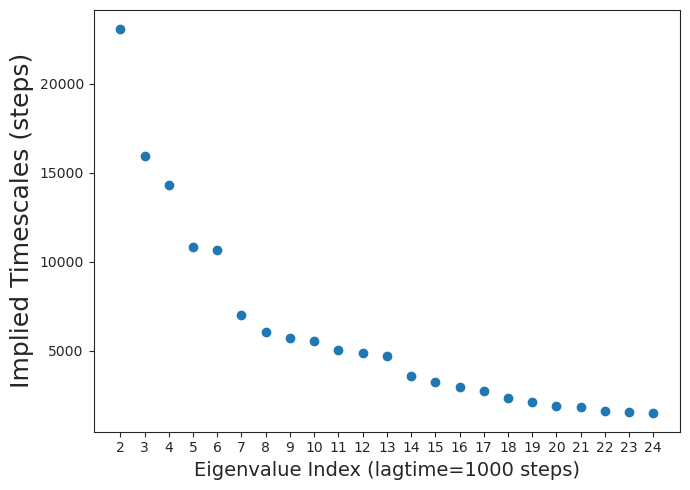

In [109]:
lagtime = 1000

counts = deeptime.markov.TransitionCountEstimator(lagtime=lagtime, count_mode="sliding").fit_fetch(discrete_trajs)
msm = deeptime.markov.msm.MaximumLikelihoodMSM().fit_from_counts(counts).fetch_model()
timescales = msm.timescales()[0:25]

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(timescales[2:], linewidth=0, marker='o') 

ax.set_xlabel(f'Eigenvalue Index (lagtime={lagtime} steps)', fontsize=14)
ax.set_ylabel('Implied Timescales (steps)', fontsize=18)

ax.set_xticks(np.arange(len(timescales[2:])))
ax.set_xticklabels(np.arange(2, len(timescales)), fontsize=10)  # Label starting from index 2
#ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

# Show the plot
plt.tight_layout()
fig.savefig('3_timescale_separation.png')
plt.show()

#### CK test

Trained MSM model with lag time 1000
Trained MSM model with lag time 2000
Trained MSM model with lag time 3000
Trained MSM model with lag time 4000
Trained MSM model with lag time 5000
Trained MSM model with lag time 6000
Trained MSM model with lag time 7000
Trained MSM model with lag time 8000


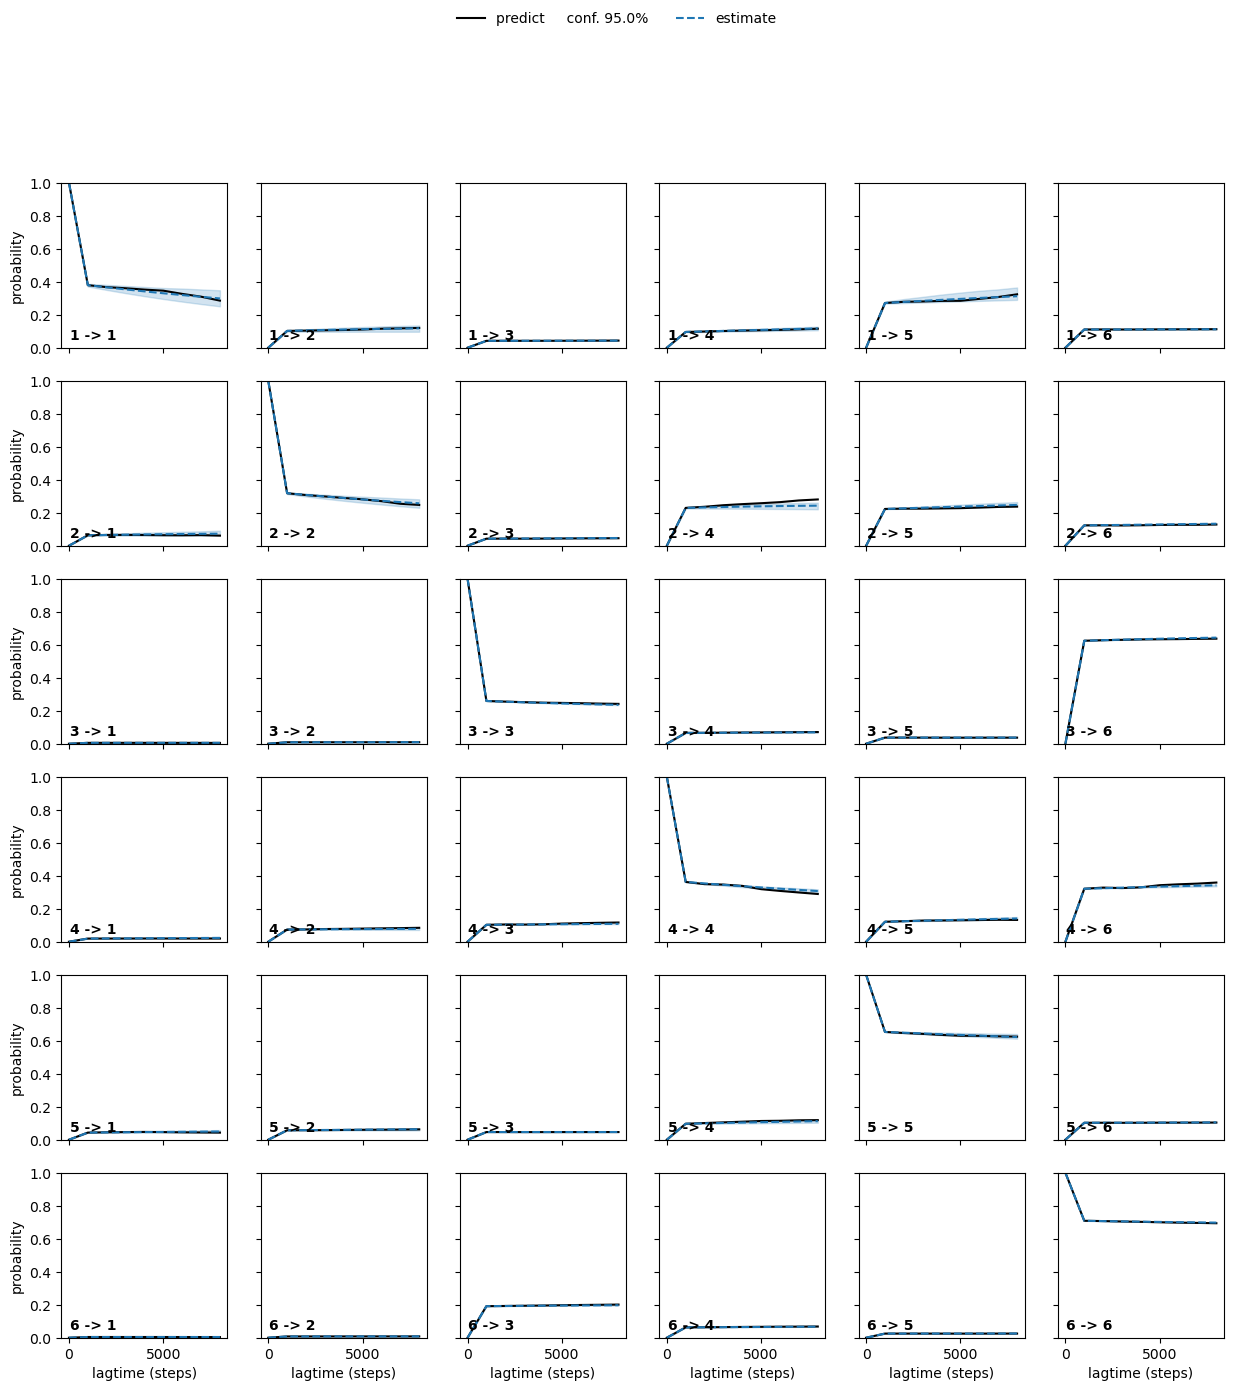

In [1]:
from deeptime.clustering import KMeans
from deeptime.data import ellipsoids
from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM, BayesianMSM
from deeptime.plots.chapman_kolmogorov import plot_ck_test
import os
import numpy as np
import matplotlib.pyplot as plt

n_sets = 6

def load_ktraj_data(data_dir):
    files = sorted([f for f in os.listdir(data_dir) if f.endswith('.npy')])
    data = [np.load(os.path.join(data_dir, f)) for f in files]
    return data

data_dir = 'ktrajs'
micro_trajs = load_ktraj_data(data_dir)
dtraj = [traj.squeeze().astype(int) for traj in micro_trajs]

# Train models with different lag times
models = []
lagt=1000
lags = [lagt *(i+1) for i in range(8)]
for lag in lags:
    counts_estimator = TransitionCountEstimator(lagtime=lag, count_mode='effective')
    model = BayesianMSM().fit_fetch(counts_estimator.fit_fetch(dtraj).submodel_largest())
    models.append(model)
    print(f"Trained MSM model with lag time {lag}")

# Perform the Chapman-Kolmogorov test
testcounts = TransitionCountEstimator(lagtime=lagt, count_mode='effective')
test_model = BayesianMSM().fit_fetch(testcounts.fit_fetch(dtraj).submodel_largest())
ck_test_results = test_model.ck_test(models, n_metastable_sets=n_sets)

# Plot the CK test results
grid = plot_ck_test(ck_test_results, legend=True)
plt.savefig('4_cktest_comparison.png')
plt.show()

# 5. Hidden Markov Model

In [111]:
import pyemma
import matplotlib.pyplot as plt
import os
import numpy as np
import deeptime.markov.hmm as hmm
from deeptime.util.validation import implied_timescales
from deeptime.plots import plot_implied_timescales

def load_ktraj_data(data_dir):
    files = sorted([f for f in os.listdir(data_dir) if f.endswith('.npy')])
    data = [np.load(os.path.join(data_dir, f)) for f in files]
    return data

data_dir = 'ktrajs'
micro_trajs = load_ktraj_data(data_dir)
discrete_trajs = [traj.flatten() for traj in micro_trajs]


#### Estimate PMM

In [121]:
estimator = deeptime.markov.hmm.init.discrete.metastable_from_data(discrete_trajs, n_hidden_states=6, lagtime=1000)

#### Estimate HMM

In [122]:
from msmbuilder.io import load_trajs, save_trajs, save_generic
import deeptime
hidden = deeptime.markov.hmm.MaximumLikelihoodHMM(initial_model=estimator, lagtime=1000).fit_fetch(discrete_trajs)
save_generic(hidden, 'hmm.pickl')

/home/samueltien/.conda/envs/pyemma/lib/python3.11/site-packages/msmbuilder/io/io.py:52: BackupWarning: hmm.pickl exists. Moving it to hmm.pickl.bak.6
  warnings.warn("{fn} exists. Moving it to {newfn}"


In [1]:
from msmbuilder.io import load_trajs, save_generic, preload_top, backup, load_generic
testhmm = load_generic("hmm.pickl")
print(testhmm.transition_model.transition_matrix)

[[9.56032692e-001 6.89582650e-109 2.99308523e-002 0.00000000e+000
  1.40364562e-002 5.80917936e-225]
 [5.91052541e-109 9.66822191e-001 9.03835884e-052 0.00000000e+000
  3.31778090e-002 0.00000000e+000]
 [1.21242417e-002 4.27154826e-052 9.63008206e-001 8.21607305e-123
  1.00772364e-002 1.47903157e-002]
 [0.00000000e+000 0.00000000e+000 7.63268461e-123 9.46724336e-001
  4.86782322e-299 5.32756637e-002]
 [3.14662557e-003 8.67751820e-003 5.57690877e-003 2.89983886e-299
  9.82598947e-001 2.72391729e-260]
 [1.94316322e-226 0.00000000e+000 1.22133960e-003 4.73559811e-003
  4.06444095e-261 9.94043062e-001]]


## HMM analysis

In [124]:
microstate_mapping = testhmm.metastable_assignments
unique_states = np.unique(microstate_mapping)
metastable_states = []

# Group indices by microstate
for state in unique_states:
    indices = np.where(microstate_mapping == state)[0].tolist()
    metastable_states.append(indices)
    
pcca_sets = metastable_states

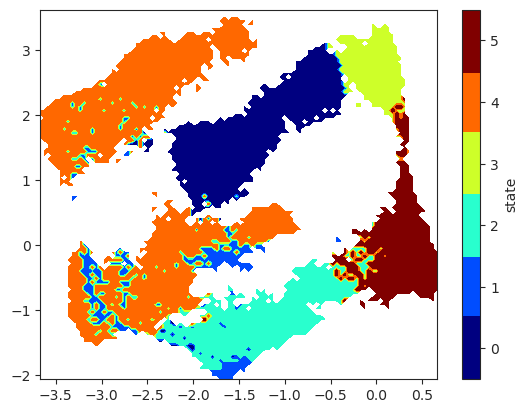

In [125]:
import pyemma
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from msmbuilder.io import load_trajs, load_generic

kclusters = load_generic('kclusters.pickl')
meta, ktrajs = load_trajs('ktrajs')
meta, ttrajs = load_trajs('ttrajs', meta)

dtrajc = np.concatenate(list(ktrajs.values()))
txx = np.concatenate(list(ttrajs.values()))

state_trajectories = np.array([microstate_mapping[dtraj] for dtraj in dtrajc])

xall = np.vstack(txx)[:, 0].flatten()
yall = np.vstack(txx)[:, 1].flatten()

# Plot state map
pyemma.plots.plot_state_map(xall, yall, state_trajectories, cmap = "jet")
plt.savefig('5_statemap.png')
plt.show()


In [126]:
import numpy as np

kclusters = load_generic('kclusters.pickl')

def get_highest_prob_indices(membership_matrix):
    membership_matrix = np.array(membership_matrix)
    highest_prob_indices = np.argmax(membership_matrix, axis=0)
    
    return highest_prob_indices.tolist()

highest_indices = get_highest_prob_indices(testhmm.metastable_memberships)

print(highest_indices)

rpos = []
xpos = kclusters.cluster_centers_[:, 0]
ypos = kclusters.cluster_centers_[:, 1]
for cluster in highest_indices:
    rpos.append([xpos[cluster], ypos[cluster]])

[17, 24, 6, 109, 12, 0]


In [2]:
testhmm = load_generic("hmm.pickl")

transition_matrix = testhmm.transition_model.transition_matrix

# Set any probabilities below 10^-10 to 0
threshold = 1e-10
transition_matrix[transition_matrix < threshold] = 0

# Renormalize the matrix along the rows
transition_matrix /= transition_matrix.sum(axis=1, keepdims=True)
print(transition_matrix)

[[0.95603269 0.         0.02993085 0.         0.01403646 0.        ]
 [0.         0.96682219 0.         0.         0.03317781 0.        ]
 [0.01212424 0.         0.96300821 0.         0.01007724 0.01479032]
 [0.         0.         0.         0.94672434 0.         0.05327566]
 [0.00314663 0.00867752 0.00557691 0.         0.98259895 0.        ]
 [0.         0.         0.00122134 0.0047356  0.         0.99404306]]


<Figure size 1000x800 with 0 Axes>

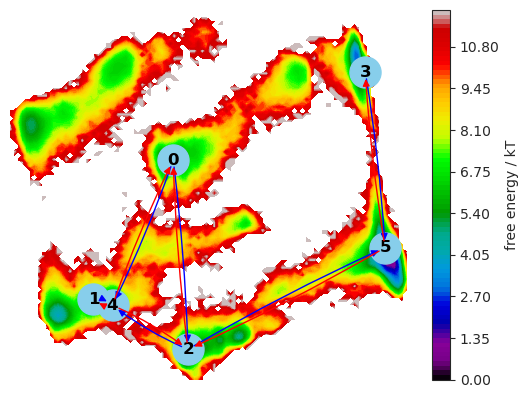

In [128]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
from msmbuilder.io import load_trajs, save_generic, preload_top, backup, load_generic
import pyemma.plots as mplt

T = transition_matrix
cluster_centers = rpos

plt.figure(figsize=(10, 8))

meta, ttrajs = load_trajs('ttrajs')
txx = np.concatenate(list(ttrajs.values()))
kclusters = load_generic('kclusters.pickl')

mplt.plot_free_energy(np.vstack(txx)[:,0], np.vstack(txx)[:,1])

G = nx.MultiDiGraph()
pos = {}
for i, center in enumerate(cluster_centers):
    G.add_node(i, pos=center)
    pos[i] = center

nx.draw(G, pos, with_labels=True, node_size=500, node_color='skyblue', font_size=12, font_weight='bold')

#add transition arrows
for i in range(T.shape[0]):
    for j in range(T.shape[1]):
        if i!=j:
            if T[i, j] > 0:
                G.add_edge(i, j, weight=T[i, j])
ax = plt.gca()
checkedge = []

# Draw arrows
for e in G.edges(data=True):
    dist = ((pos[e[0]][0]-pos[e[1]][0])**2 + (pos[e[0]][1]-pos[e[1]][1])**2)**(0.5)
    check = [e[0], e[1]]
    if check in checkedge:
        arrow_color = 'red'
    else:
        arrow_color = 'blue'
    checkedge.append([e[1], e[0]])
    ax.annotate("",
                xy=pos[e[0]], xycoords='data',
                xytext=pos[e[1]], textcoords='data',
                arrowprops=dict(arrowstyle="<|-", color=arrow_color,
                                shrinkA=5, shrinkB=5,
                                patchA=None, patchB=None,
                                connectionstyle="arc3,rad=rrr".replace('rrr', str(0.07/(dist+0.07))),
                                ),
                )
#plt.title("TITLE")
plt.savefig('5_transitiondiagram_hmm.png')

In [129]:
print(testhmm.transition_model.stationary_distribution)

[0.02401017 0.02801273 0.05927338 0.06380382 0.10710447 0.71779544]


#### Sample representative frames

In [130]:
import mdtraj as md
import os

from msmbuilder.io.sampling import sample_states
from msmbuilder.io import load_trajs, save_generic, preload_top, backup, load_generic

import matplotlib
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import pyemma.plots as mplt

## Load
meta, ttrajs = load_trajs('ttrajs')
kclusters = load_generic("kclusters.pickl")

microstate_mapping = testhmm.metastable_assignments
unique_states = np.unique(microstate_mapping)
metastable_states = []

avgpos = []
for cluster in highest_indices:
    avgpos.append(kclusters.cluster_centers_[cluster])

## Sample
inds = sample_states(ttrajs,
                     avgpos,
                     k=30)
save_generic(inds, "cg-sample-inds.pickl")

## Make trajectories
top = preload_top(meta)
out_folder = "5_coarsegrained_hmm"
backup(out_folder)
os.mkdir(out_folder)

index_file = os.path.join(out_folder, "index.txt")

with open(index_file, 'w') as f:
    f.write("State\tTrajectory\tFrame\n")  # Header

    for state_i, state_inds in enumerate(inds):
        traj = md.join(
            md.load_frame(meta.loc[traj_i]['traj_fn'], index=frame_i, top=top)
            for traj_i, frame_i in state_inds
        )
        traj.save("{}/{}.xtc".format(out_folder, state_i))

        # Write the indices to the file
        for traj_i, frame_i in state_inds:
            f.write(f"{state_i}\t{traj_i}\t{frame_i}\n")

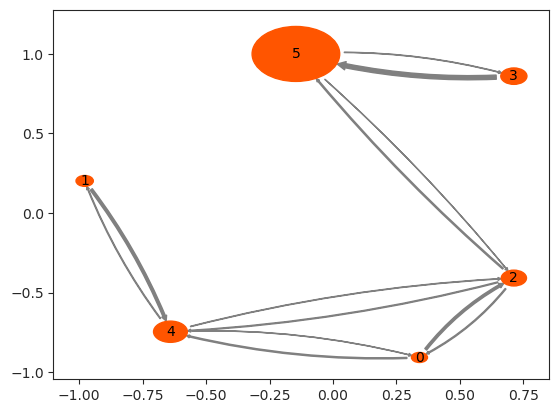

In [133]:
##plot network map

import deeptime

deeptime.plots.plot_markov_model(msm=transition_matrix, edge_labels = None)
plt.savefig("5_transition_model")